# 目录
[1. 项目介绍](#1)<br>
[2. 数据读取与查看](#2)<br>
&ensp;&ensp;[2.1 数据集介绍](#2.1)<br>
&ensp;&ensp;[2.2 读取数据](#2.2)<br>
&ensp;&ensp;[2.3 查看数据基本信息](#2.3)<br>
[3. 数据预处理](#3)<br>
[4. 数据可视化](#4)<br>
&ensp;&ensp;[4.1 数据集中不同特征之间的相关性热力图](#4.1)<br>
&ensp;&ensp;[4.2 不同特征的分布](#4.2)<br>
&ensp;&ensp;[4.3 年龄、月收入、教育背景关系](#4.3)<br>
&ensp;&ensp;[4.4 性别与教育背景的关系](#4.4)<br>
&ensp;&ensp;[4.5 各个属性与订单状态和反馈的情况](#4.5)<br>
&ensp;&ensp;[4.6 家庭人数、年龄与订单状态的关系](#4.6)<br>
[5. 训练集测试集划分](#5)<br>
[6. 模型构建与拟合](#6)<br>
[7. 模型预测与评估](#7)<br>
&ensp;&ensp;[7.1 模型预测](#7.1)<br>
&ensp;&ensp;[7.2 模型评估](#7.2)<br>
&ensp;&ensp;[7.3 不同模型效果对比（随机森林与XGBoost）](#7.3)<br>
&ensp;&ensp;[7.4 模型预测结论](#7.4)<br>
[8. 总结](#8)<br>

<a id="1"></a>

# 1. 项目介绍

&ensp;&ensp;在数字化时代，食品行业不断迎来新的挑战和变革。传统的实体店面对着越来越多的电商平台和在线食品服务的竞争，消费者的购物行为也呈现出多样化和个性化的趋势。与此同时，移动支付技术和智能手机的普及使得在线订购食品变得更加便捷和高效。<br>
&ensp;&ensp;随着数据采集技术和数据处理能力的提升，企业能够收集和分析大量的在线食品订单数据。这些数据不仅包括消费者的购买历史和偏好，还涉及到产品的供应链信息和市场的竞争态势。因此，通过有效地利用数据科学和机器学习方法，可以从这些数据中挖掘出宝贵的商业洞察，并为企业的发展提供战略指导。<br>
&ensp;&ensp;总体而言，本项目旨在探讨如何利用数据科学技术对在线食品订单数据进行分析和建模，以揭示其中的规律和趋势，并探讨这些研究对于提升企业竞争力和消费者满意度的实际意义。<br>

<a id="2"></a>

# 2. 数据读取与查看

<a id="2.1"></a>

## 2.1 数据集介绍 

&ensp;&ensp;本次实验数据集从kaggle中获取，数据集为onlinefoods.csv，共有12个字段。首先，简单介绍一下各字段的含义。

| 列名	| 含义说明|
| :----: | :----: |
| Age | 年龄 |
| Gender | 性别 |
| Marital Status | 婚姻状态 |
| Occupation | 职业 |
| Monthly Income | 月收入 |
| Educational Qualifications | 教育背景 |
| Family size | 家庭人数 |
| latitude | 纬度 |
| longitude | 经度 |
| Pin code | 邮政编码 |
| Output | 订单状态 |
| Feedback | 反馈 |

&ensp;&ensp;在`2.3 查看数据基本信息`中我们将使用`shape()`方法查看数据集的行数及列数，了解数据集的大小。使用`info()`方法打印DataFrame对象的摘要，包括列的数据类型dtype、名称以及有无缺失值，占用的内存等信息。使用`describe()`方法查看数据的描述性统计。

<a id="2.2"></a>

## 2.2 读取数据

In [2]:
# 导入需要用到的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from pyecharts.charts import Bar, Timeline
from pyecharts import options as opts
from pyecharts.globals import ThemeType
from itertools import product
import pyecharts
sns.set_theme(style="darkgrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [3]:
# 读入数据集
data = pd.read_csv('onlinefoods.csv')
data.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [4]:
# 将索引替换为中文列名
data.columns = ['年龄', '性别', '婚姻状态', '职业', '月收入', '教育背景', '家庭人数', '纬度', '经度', '邮政编码', '订单状态', '反馈', 'Unnamed: 12']
data.head()

,年龄,性别,婚姻状态,职业,月收入,教育背景,家庭人数,纬度,经度,邮政编码,订单状态,反馈,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


<a id="2.3"></a>

## 2.3 查看数据基本信息

In [5]:
data.shape

(388, 13)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   年龄           388 non-null    int64  
 1   性别           388 non-null    object 
 2   婚姻状态         388 non-null    object 
 3   职业           388 non-null    object 
 4   月收入          388 non-null    object 
 5   教育背景         388 non-null    object 
 6   家庭人数         388 non-null    int64  
 7   纬度           388 non-null    float64
 8   经度           388 non-null    float64
 9   邮政编码         388 non-null    int64  
 10  订单状态         388 non-null    object 
 11  反馈           388 non-null    object 
 12  Unnamed: 12  388 non-null    object 
dtypes: float64(2), int64(3), object(8)
memory usage: 39.5+ KB


In [7]:
# 查看数值型变量的描述性统计
data.describe()

,年龄,家庭人数,纬度,经度,邮政编码
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [8]:
# 查看非数值型变量的描述性统计
data.describe(include='O')

,性别,婚姻状态,职业,月收入,教育背景,订单状态,反馈,Unnamed: 12
count,388,388,388,388,388,388,388,388
unique,2,3,4,5,5,2,2,2
top,Male,Single,Student,No Income,Graduate,Yes,Positive,Yes
freq,222,268,207,187,177,301,317,301


In [9]:
# 查看非数值型变量的具体描述，unique值
for column in data.select_dtypes(include=['object']).columns:
    print(f"Unique values for {column}: {data[column].unique()}")

Unique values for 性别: ['Female' 'Male']
Unique values for 婚姻状态: ['Single' 'Married' 'Prefer not to say']
Unique values for 职业: ['Student' 'Employee' 'Self Employeed' 'House wife']
Unique values for 月收入: ['No Income' 'Below Rs.10000' 'More than 50000' '10001 to 25000'
 '25001 to 50000']
Unique values for 教育背景: ['Post Graduate' 'Graduate' 'Ph.D' 'Uneducated' 'School']
Unique values for 订单状态: ['Yes' 'No']
Unique values for 反馈: ['Positive' 'Negative ']
Unique values for Unnamed: 12: ['Yes' 'No']


<a id="3"></a>

# 3. 数据预处理

In [10]:
# 非数值型变量替换成中文
# 替换 '性别' 列中的值
data['性别'] = data['性别'].replace({
    'Female': '女性',
    'Male': '男性'
})

# 替换 '婚姻状态' 列中的值
data['婚姻状态'] = data['婚姻状态'].replace({
    'Single': '单身',
    'Married': '已婚',
    'Prefer not to say': '不愿透露'
})

# 替换 '职业' 列中的值
data['职业'] = data['职业'].replace({
    'Student': '学生',
    'Employee': '员工',
    'Self Employeed': '自雇',
    'House wife': '家庭主妇'
})

# 替换 '月收入' 列中的值
data['月收入'] = data['月收入'].replace({
    'No Income': '无收入',
    'Below Rs.10000': '低于10000元',
    'More than 50000': '超过50000元',
    '10001 to 25000': '10001到25000元',
    '25001 to 50000': '25001到50000元'
})

# 替换 '教育背景' 列中的值
data['教育背景'] = data['教育背景'].replace({
    'Post Graduate': '研究生',
    'Graduate': '本科',
    'Ph.D': '博士',
    'Uneducated': '未受教育',
    'School': '中学'
})

# 替换 '订单状态' 列中的值
data['订单状态'] = data['订单状态'].replace({
    'Yes': '是',
    'No': '否'
})

# 替换 '反馈' 列中的值
data['反馈'] = data['反馈'].replace({
    'Positive': '积极',
    'Negative ': '消极'
})

# 替换 'Unnamed: 12' 列中的值
data['Unnamed: 12'] = data['Unnamed: 12'].replace({
    'Yes': '是',
    'No': '否'
})

# 查看更新后的数据
data.head()

,年龄,性别,婚姻状态,职业,月收入,教育背景,家庭人数,纬度,经度,邮政编码,订单状态,反馈,Unnamed: 12
0,20,女性,单身,学生,无收入,研究生,4,12.9766,77.5993,560001,是,积极,是
1,24,女性,单身,学生,低于10000元,本科,3,12.9770,77.5773,560009,是,积极,是
2,22,男性,单身,学生,低于10000元,研究生,3,12.9551,77.6593,560017,是,消极,是
3,22,女性,单身,学生,无收入,本科,6,12.9473,77.5616,560019,是,积极,是
4,22,男性,单身,学生,低于10000元,研究生,4,12.9850,77.5533,560010,是,积极,是


In [11]:
# 再次查看非数值型变量的具体描述，unique值
for column in data.select_dtypes(include=['object']).columns:
    print(f"Unique values for {column}: {data[column].unique()}")

Unique values for 性别: ['女性' '男性']
Unique values for 婚姻状态: ['单身' '已婚' '不愿透露']
Unique values for 职业: ['学生' '员工' '自雇' '家庭主妇']
Unique values for 月收入: ['无收入' '低于10000元' '超过50000元' '10001到25000元' '25001到50000元']
Unique values for 教育背景: ['研究生' '本科' '博士' '未受教育' '中学']
Unique values for 订单状态: ['是' '否']
Unique values for 反馈: ['积极' '消极']
Unique values for Unnamed: 12: ['是' '否']


In [12]:
#查看订单状态和没有命名的那一列是否完全相同
data['out_unname'] = np.where(data['订单状态']==data['Unnamed: 12'],False,True)
data['out_unname'].any()

False

In [13]:
#可以看到这两列完全相同，删掉最后一列
data.drop(['Unnamed: 12','out_unname'],axis=1,inplace=True)
data.head()

,年龄,性别,婚姻状态,职业,月收入,教育背景,家庭人数,纬度,经度,邮政编码,订单状态,反馈
0,20,女性,单身,学生,无收入,研究生,4,12.9766,77.5993,560001,是,积极
1,24,女性,单身,学生,低于10000元,本科,3,12.9770,77.5773,560009,是,积极
2,22,男性,单身,学生,低于10000元,研究生,3,12.9551,77.6593,560017,是,消极
3,22,女性,单身,学生,无收入,本科,6,12.9473,77.5616,560019,是,积极
4,22,男性,单身,学生,低于10000元,研究生,4,12.9850,77.5533,560010,是,积极


In [14]:
# 查看数据缺失值情况，这里可以看到数据没有缺失值
data.isnull().sum()

年龄      0
性别      0
婚姻状态    0
职业      0
月收入     0
教育背景    0
家庭人数    0
纬度      0
经度      0
邮政编码    0
订单状态    0
反馈      0
dtype: int64

In [15]:
# 查看数据重复值情况,发现有重复数据，进行删除处理
data.duplicated().sum()

103

In [16]:
#删除所有重复行
data.drop_duplicates(inplace=True)
data.duplicated().sum()

0

In [17]:
data.head()

,年龄,性别,婚姻状态,职业,月收入,教育背景,家庭人数,纬度,经度,邮政编码,订单状态,反馈
0,20,女性,单身,学生,无收入,研究生,4,12.9766,77.5993,560001,是,积极
1,24,女性,单身,学生,低于10000元,本科,3,12.9770,77.5773,560009,是,积极
2,22,男性,单身,学生,低于10000元,研究生,3,12.9551,77.6593,560017,是,消极
3,22,女性,单身,学生,无收入,本科,6,12.9473,77.5616,560019,是,积极
4,22,男性,单身,学生,低于10000元,研究生,4,12.9850,77.5533,560010,是,积极


<a id="4"></a>

# 4. 数据可视化

<a id="4.1"></a>

## 4.1 数据集中不同特征之间的相关性热力图

&ensp;&ensp;对数据集中不同特征之间的相关性进行热力图可视化，以帮助我们更好的了解数据集中不同特征之间的相关性从而优化数据可视化策略与建模准备。

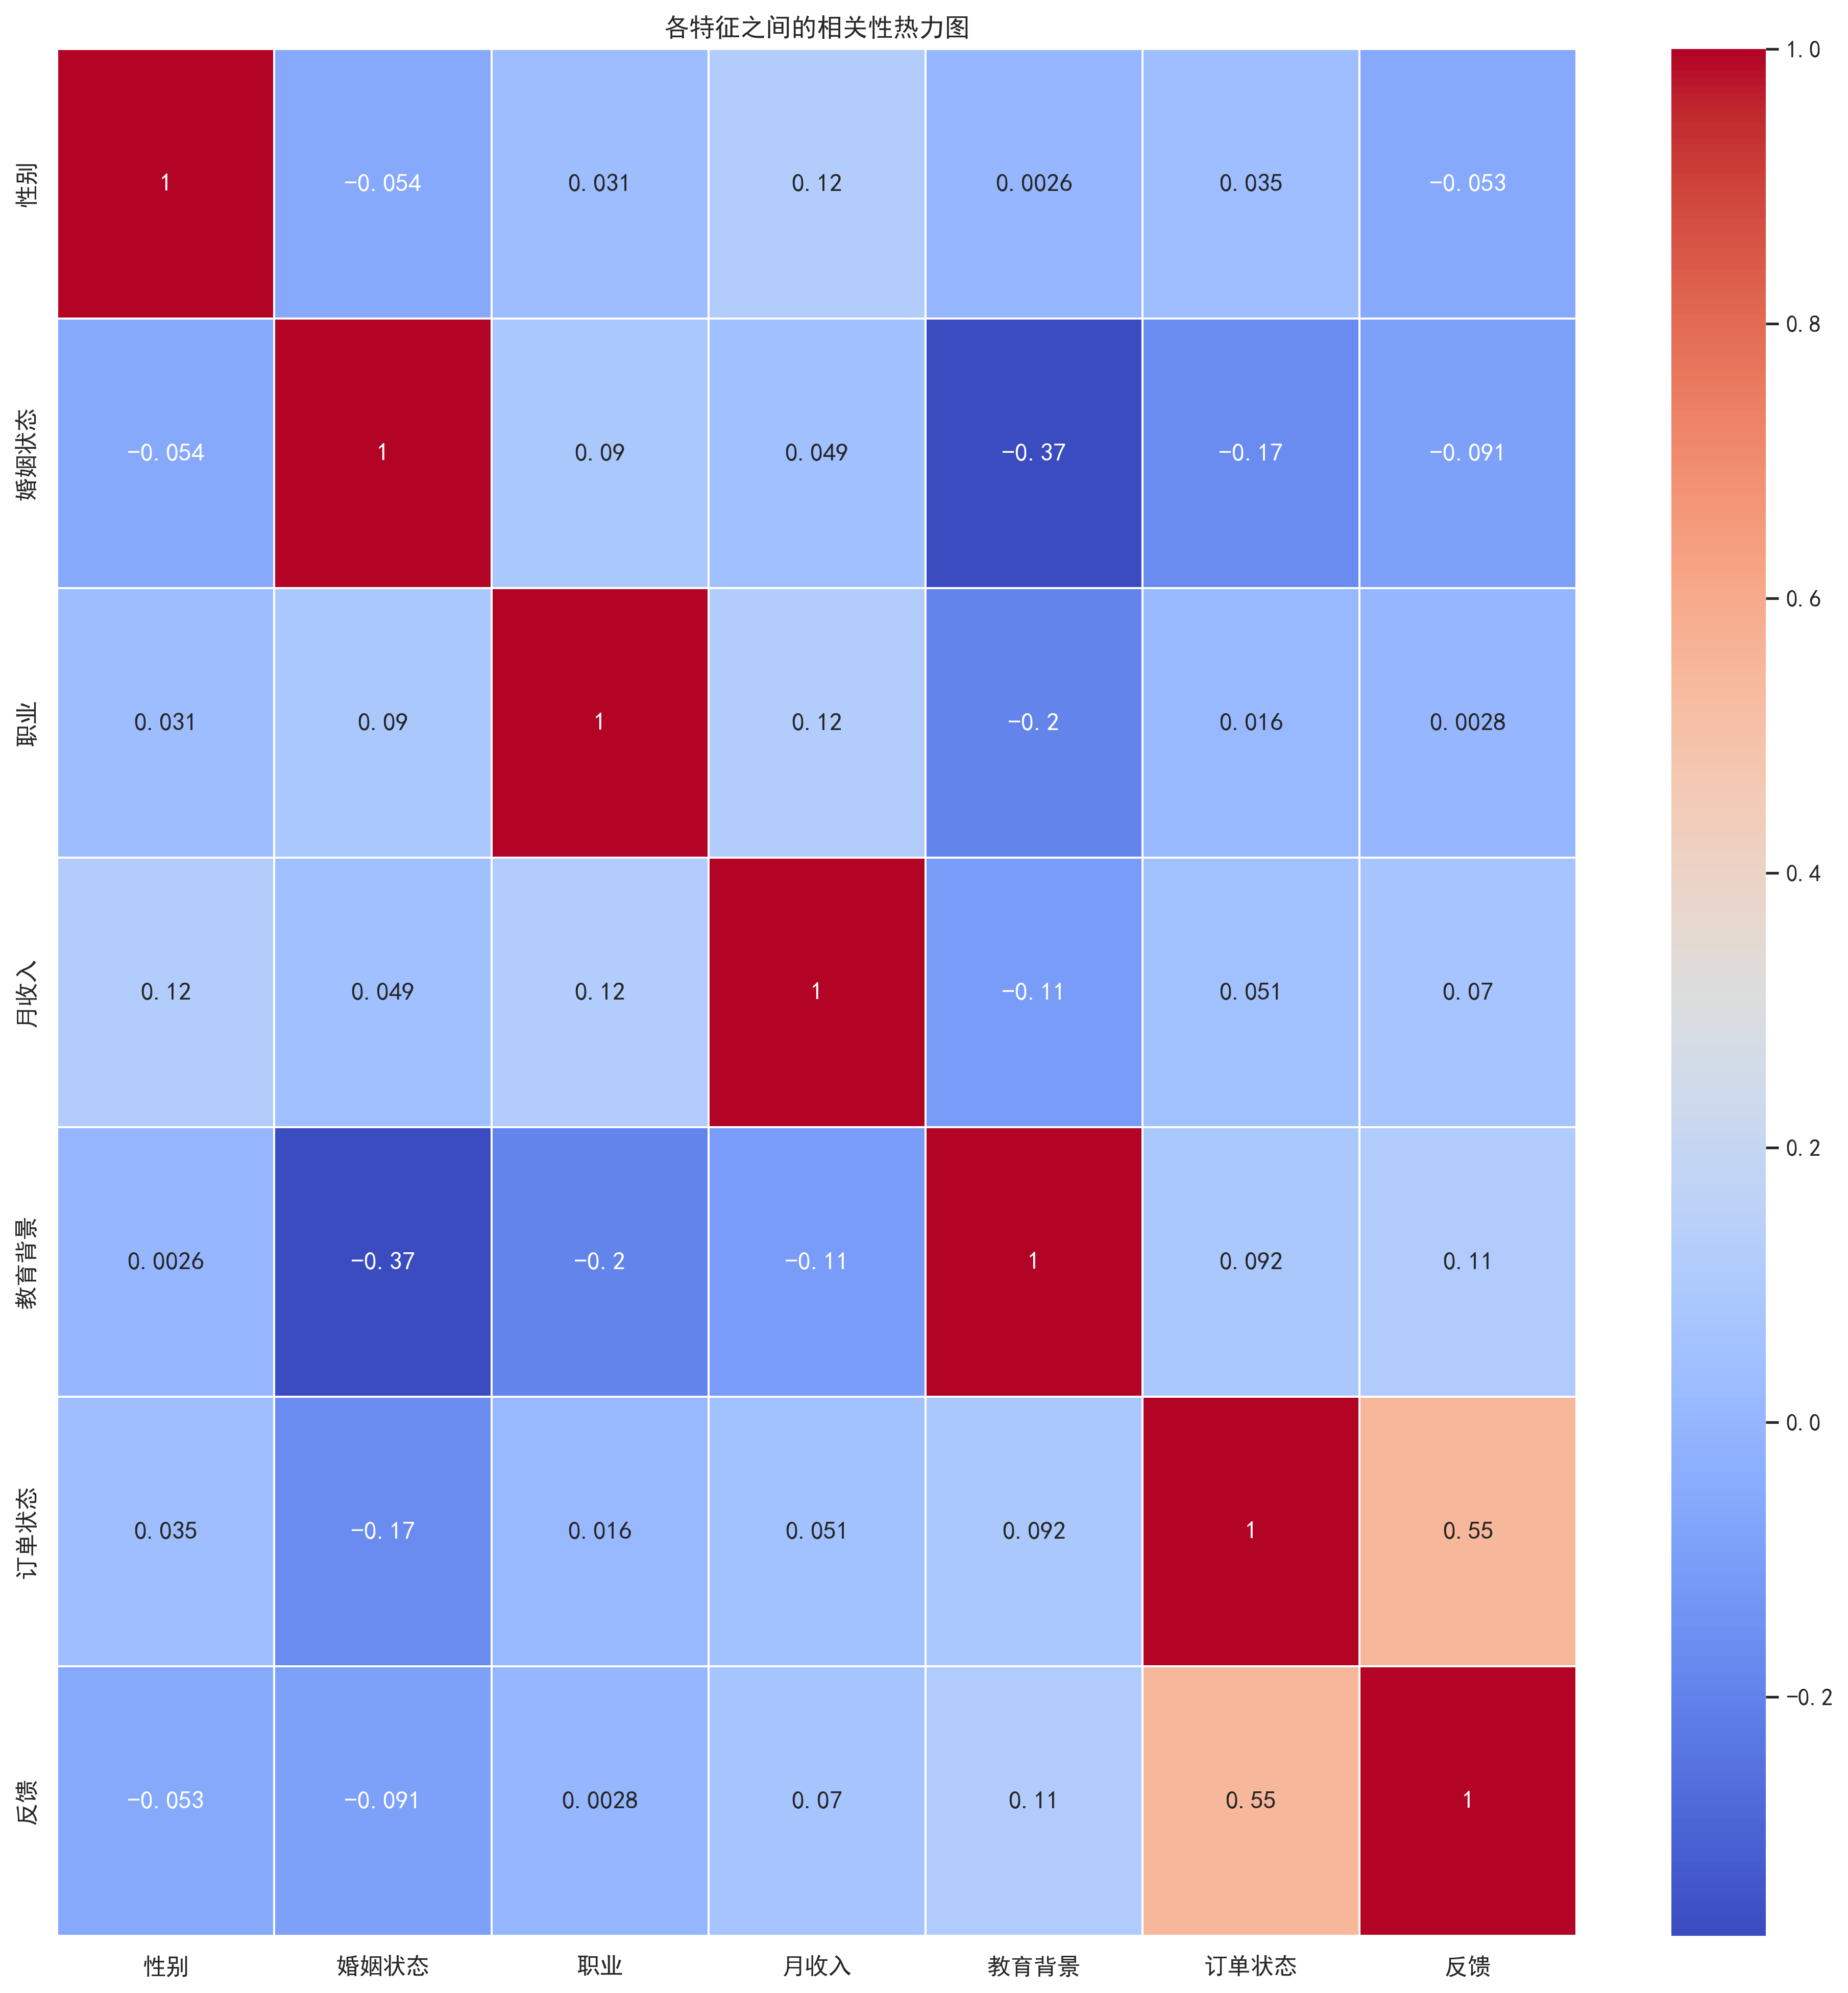

In [18]:
# 各特征间相关性热力图
# 对性别、婚姻状态等非数值型变量列进行编码
data1 = data.loc[:,['性别', '婚姻状态', '职业', '月收入', '教育背景', '订单状态', '反馈']]

#对非数值型变量进行编码
for i in data1.columns:
    data1[i] = data1[i].astype("category").cat.codes

#绘图
plt.figure(figsize=(16,16), dpi=300)
sns.heatmap(data1.corr(),annot=True,cmap='coolwarm',linewidths=0.9)
plt.title('各特征之间的相关性热力图')
plt.show()

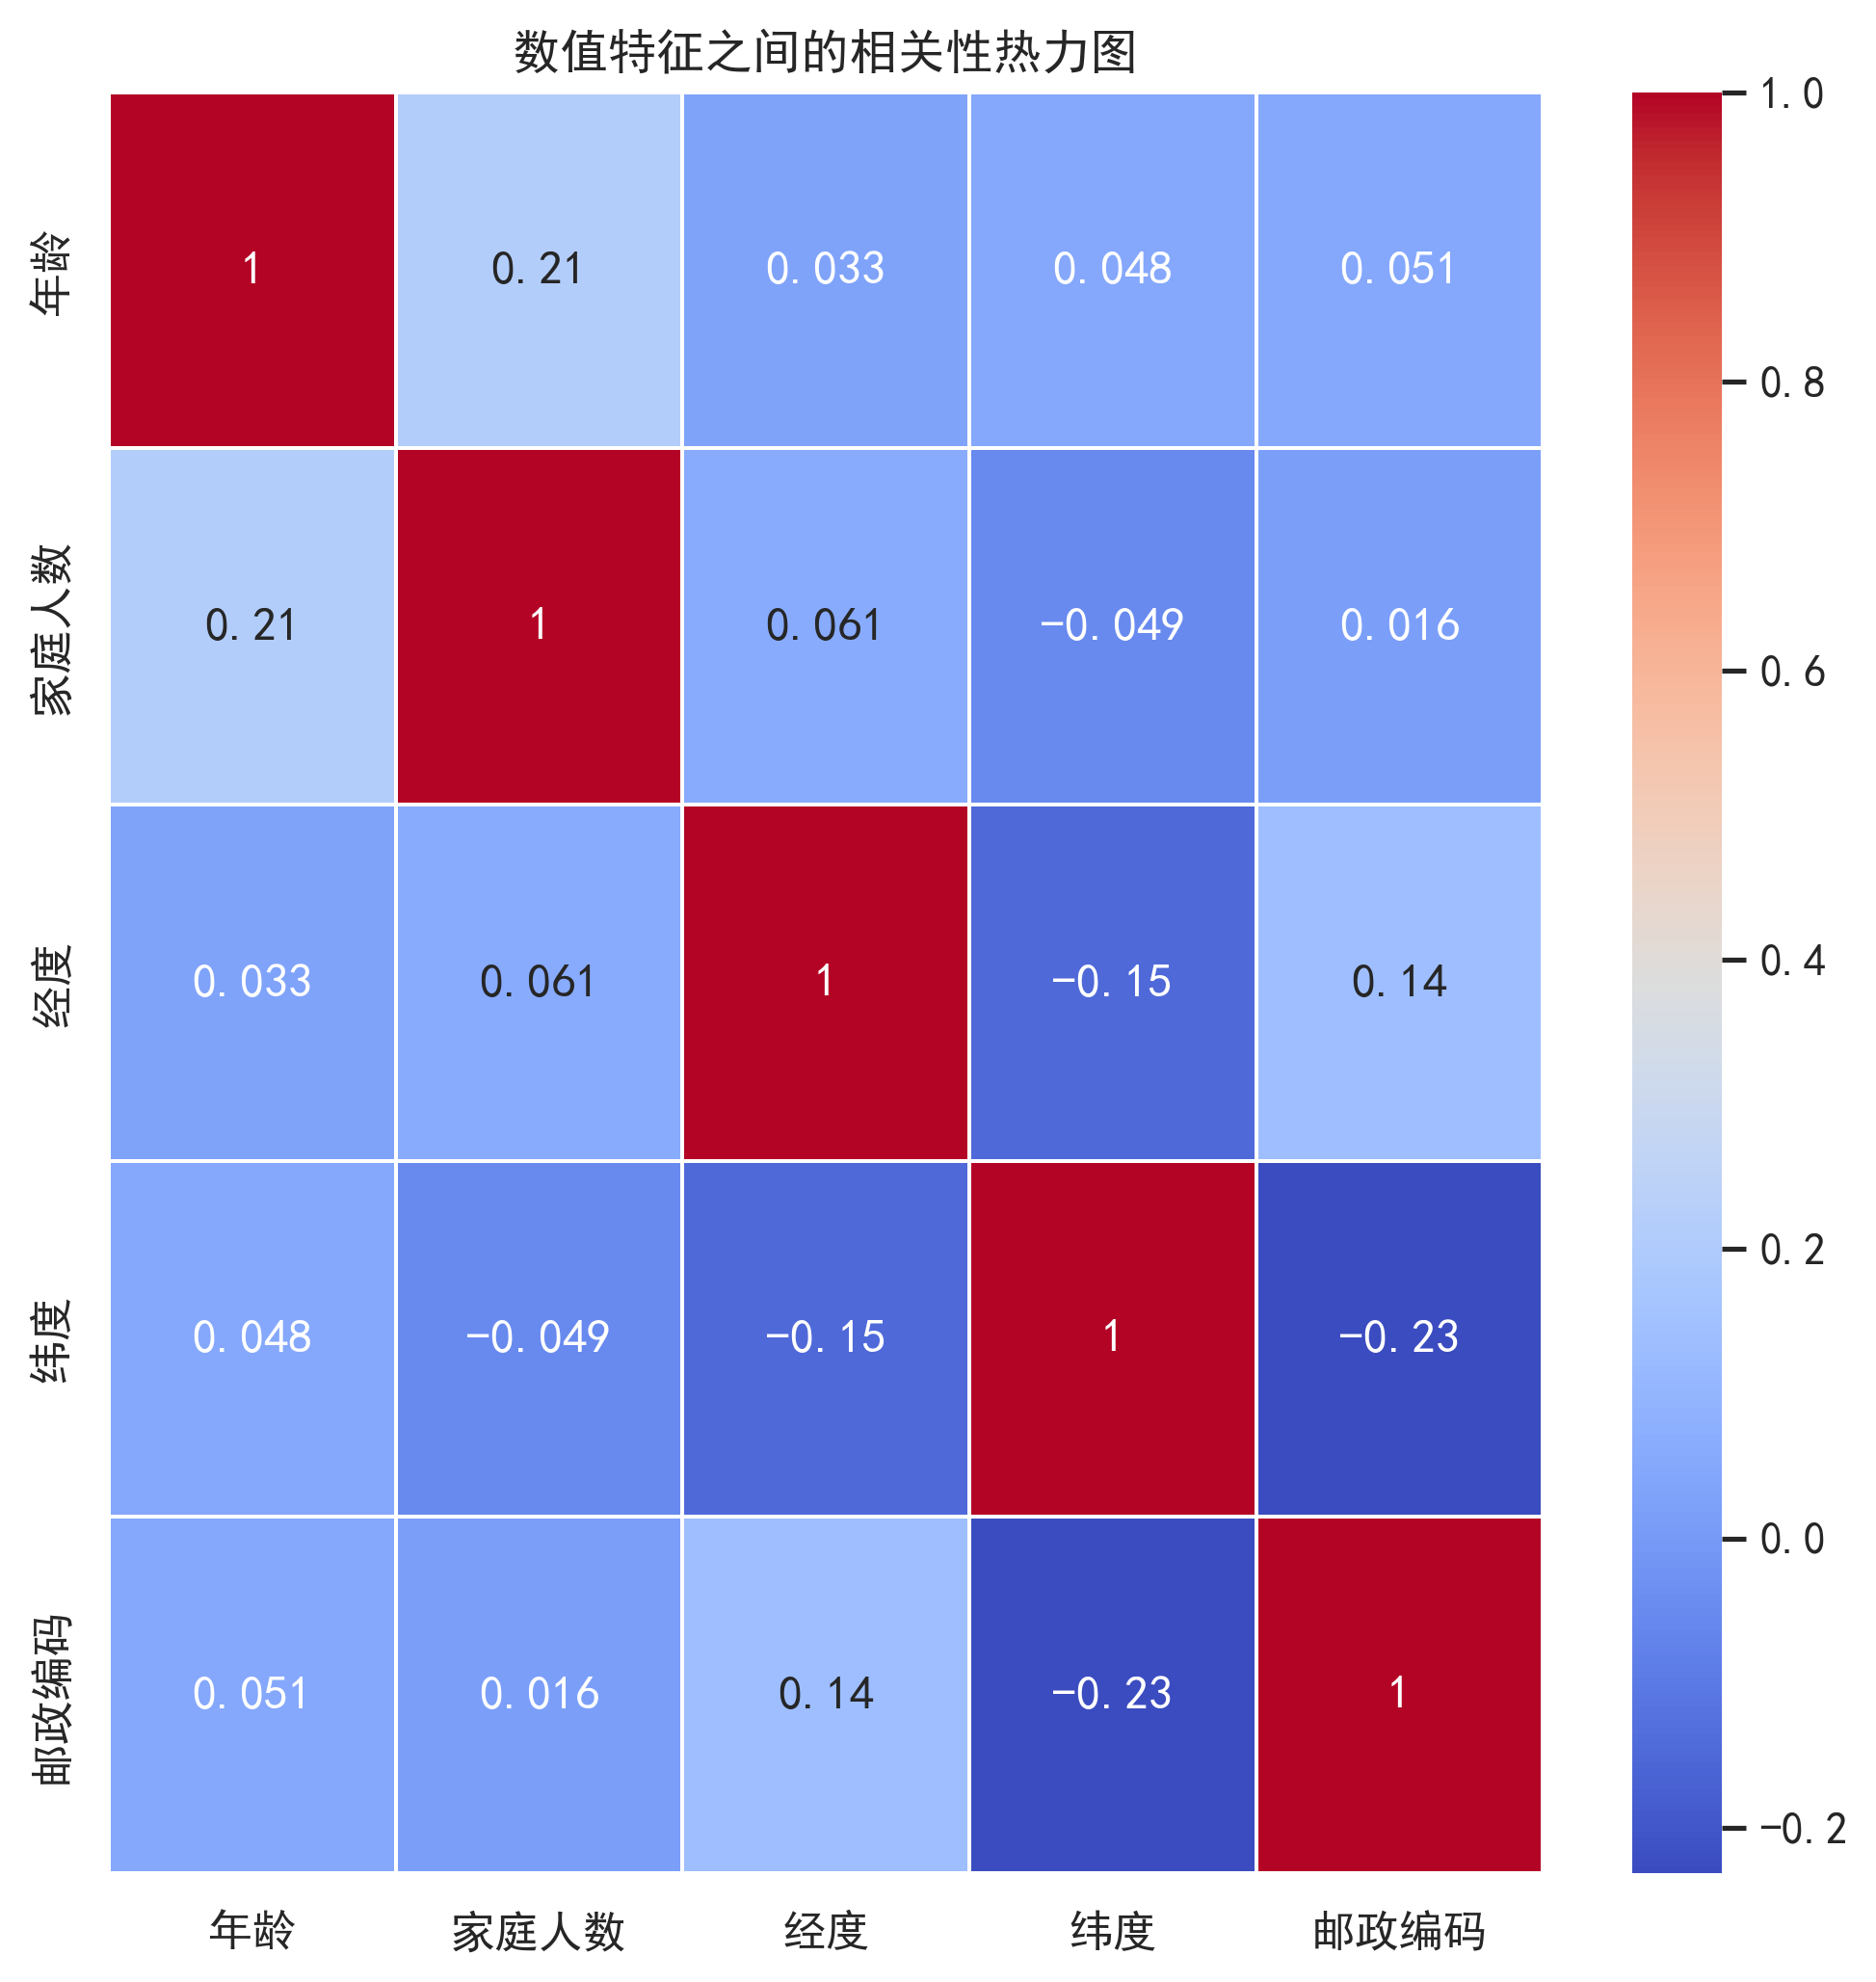

In [19]:
# 数值型特征间相关性热力图
data2 = data[['年龄','家庭人数','经度','纬度','邮政编码']]

#绘图
plt.figure(figsize=(8, 8), dpi=300)
sns.heatmap(data2.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('数值特征之间的相关性热力图')
plt.show()

<a id="4.2"></a>

## 4.2 不同特征的分布

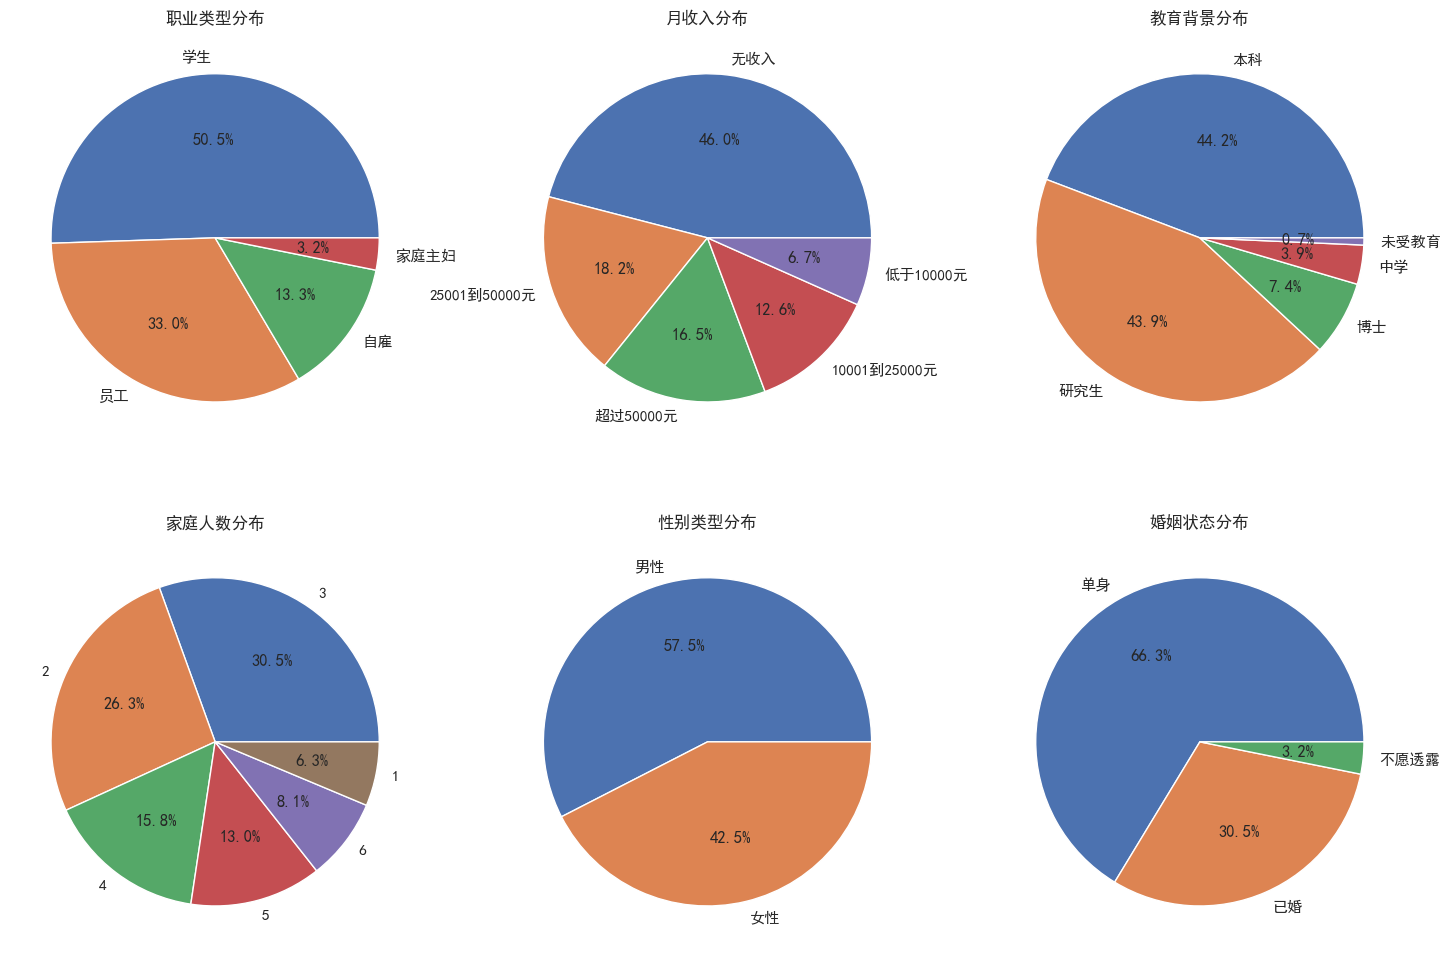

In [20]:
#绘制不同的圆饼图
fig = plt.figure(figsize=(18,12))

#绘制职业分布圆饼图
fig.add_subplot(231)
zhiye_state = data['职业'].value_counts()
plt.pie(zhiye_state,labels=zhiye_state.index,autopct='%.1f%%')
plt.title("职业类型分布")

#绘制月收入圆饼图
fig.add_subplot(232)
yueshouru_state = data['月收入'].value_counts()
plt.pie(yueshouru_state,labels=yueshouru_state.index,autopct='%.1f%%')
plt.title("月收入分布")


#绘制教育背景圆饼图
fig.add_subplot(233)
zhiye_state = data['教育背景'].value_counts()
plt.pie(zhiye_state,labels=zhiye_state.index,autopct='%.1f%%')
plt.title("教育背景分布")

#绘制家庭人数圆饼图
fig.add_subplot(234)
yueshouru_state = data['家庭人数'].value_counts()
plt.pie(yueshouru_state,labels=yueshouru_state.index,autopct='%.1f%%')
plt.title("家庭人数分布")

#绘制性别分布圆饼图
fig.add_subplot(235)
zhiye_state = data['性别'].value_counts()
plt.pie(zhiye_state,labels=zhiye_state.index,autopct='%.1f%%')
plt.title("性别类型分布")

#绘制婚姻状态圆饼图
fig.add_subplot(236)
yueshouru_state = data['婚姻状态'].value_counts()
plt.pie(yueshouru_state,labels=yueshouru_state.index,autopct='%.1f%%')
plt.title("婚姻状态分布")


plt.show()

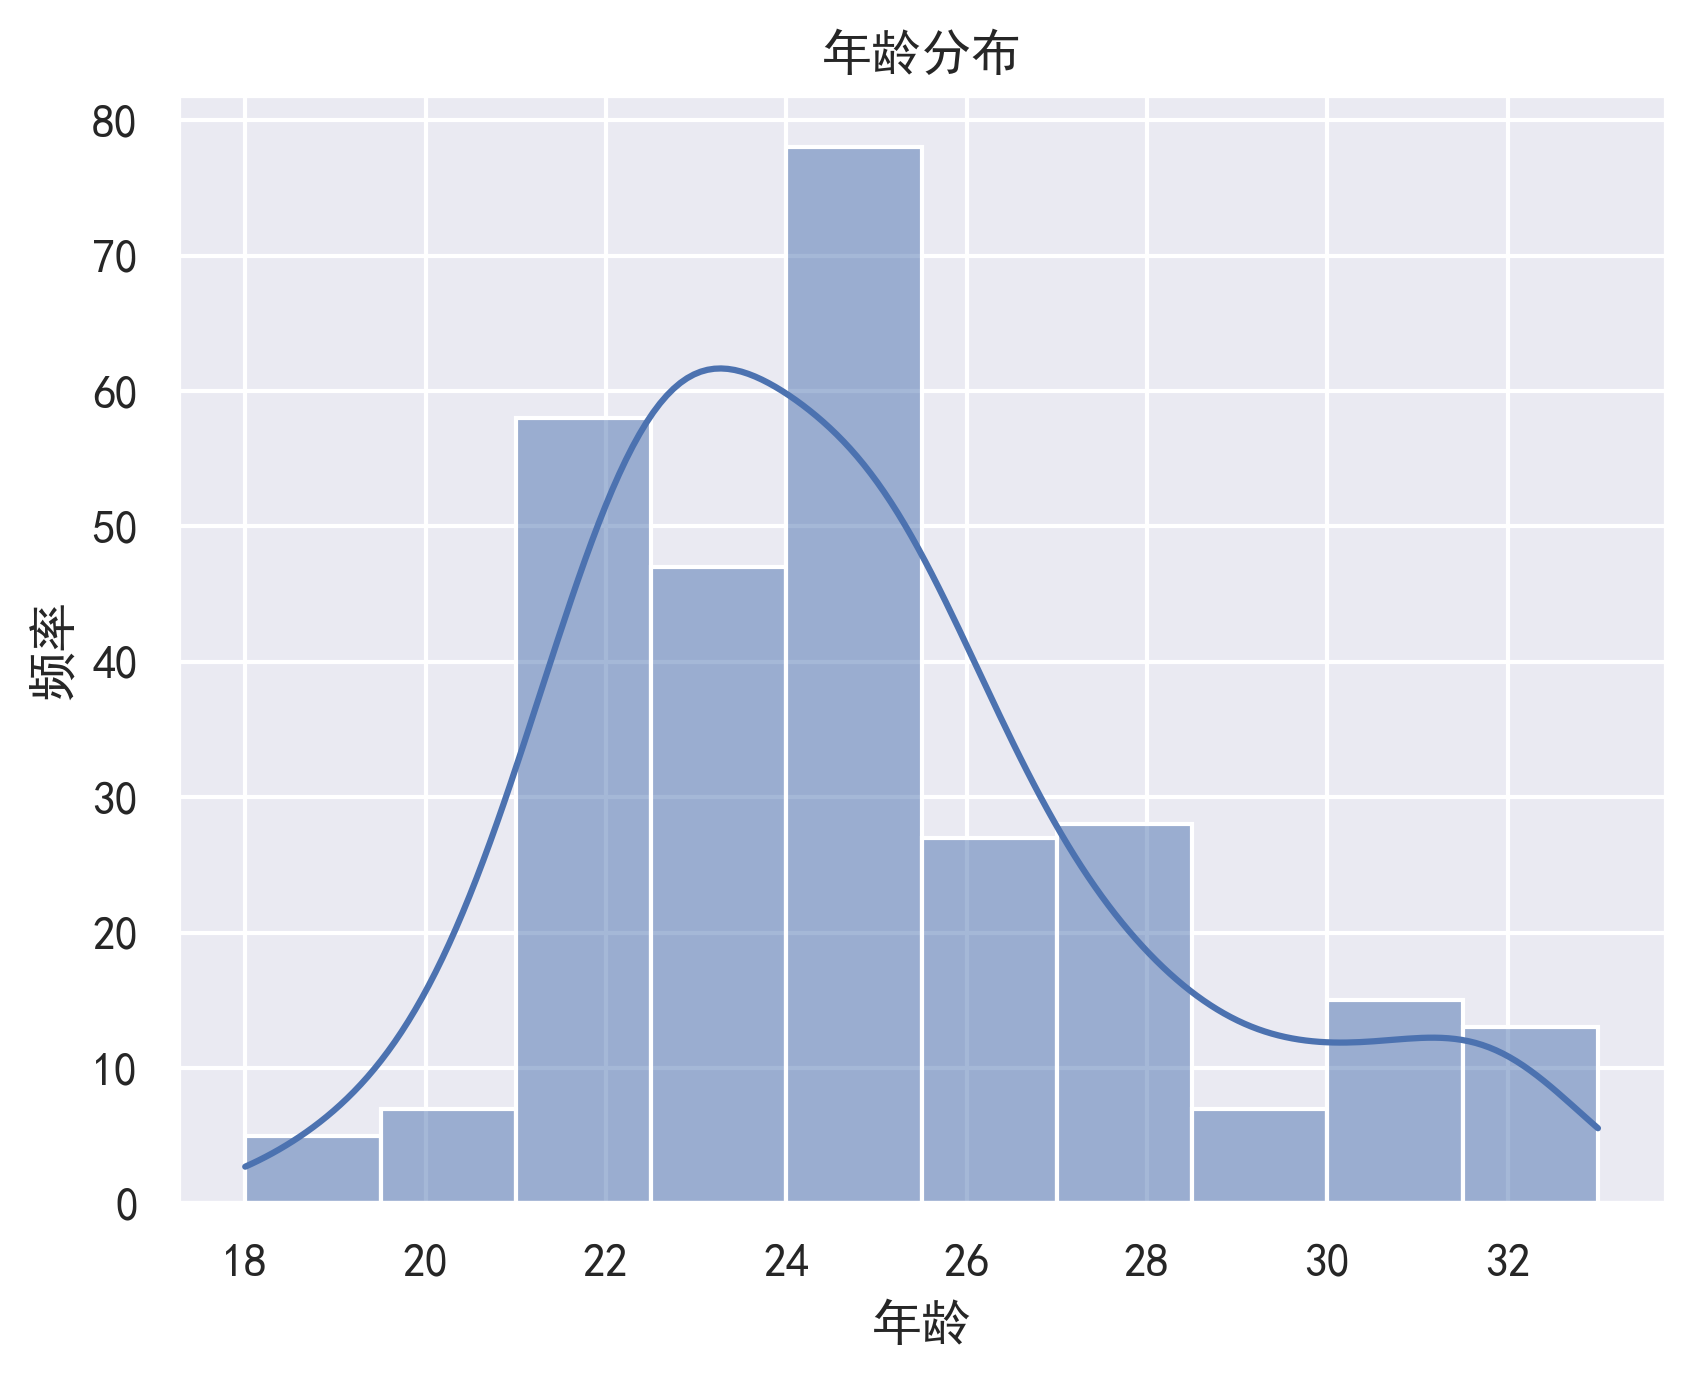

In [21]:
plt.figure(dpi=300)
sns.histplot(data['年龄'], bins=10, kde=True)
plt.title('年龄分布')
plt.xlabel('年龄')
plt.ylabel('频率')
plt.show()

In [22]:
import plotly.express as px
#通过经纬度绘制地图
jw_yz = data.groupby(['纬度', '经度','邮政编码']).size().reset_index(name='数量')

fig = px.scatter_mapbox(jw_yz, 
                        lat="纬度", 
                        lon="经度", 
                        size="数量",  # 气泡大小
                        color="邮政编码",  # 按邮政编码着色
                        hover_name="邮政编码",  # 鼠标悬停时显示邮政编码
                        zoom=10,  # 地图缩放级别
                        mapbox_style="open-street-map")

fig.show()

<a id="4.3"></a>

## 4.3 年龄、月收入、教育背景关系

In [23]:
sns.set_theme(style="darkgrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

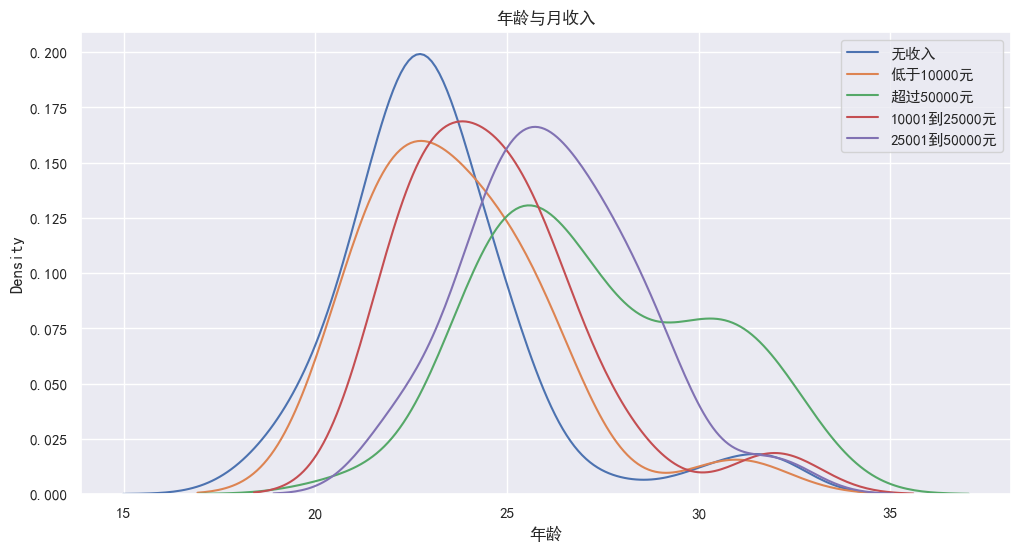

In [24]:
#绘制年龄与月收入之间的关系
plt.figure(figsize=(12,6))

#提权不同的月收入
for shouru_type in data['月收入'].unique():
    sns.kdeplot(data[data['月收入']==shouru_type]['年龄'],label=shouru_type)
plt.title("年龄与月收入")
plt.legend()

C:\Users\86152\AppData\Local\Temp\ipykernel_26580\858476426.py:25: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



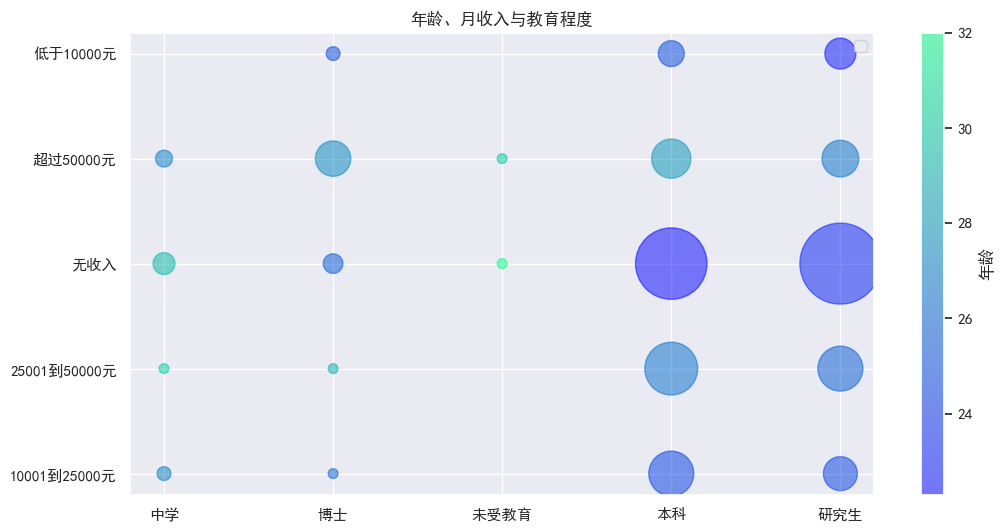

In [25]:
#绘制月收入、年龄和教育背景的气泡图
plt.figure(figsize=(12,6))

#获取不同教育背景与月收入之间的数量关系
jiaoyu_shouru_counts = data.groupby(['教育背景', '月收入']).size().reset_index(name='数量')

#获取不同教育背景与月收入人群的平均年龄
average_age = data.groupby(['教育背景', '月收入'])['年龄'].mean().reset_index(name='平均年龄')

#整合数据
jiaoyu_shouru_counts_with_age = jiaoyu_shouru_counts.merge(average_age, on=['教育背景', '月收入'])

#绘制图像
plt.scatter(jiaoyu_shouru_counts_with_age['教育背景'],
            jiaoyu_shouru_counts_with_age['月收入'],
            s=jiaoyu_shouru_counts_with_age['数量']*50,
            c=jiaoyu_shouru_counts_with_age['平均年龄'],
            alpha=0.5,
            cmap='winter'
)

#sns.swarmplot(x="教育背景",y="月收入",data=data)
plt.title("年龄、月收入与教育程度")

plt.legend()
cbar = plt.colorbar()
cbar.set_label('年龄') 


<a id="4.4"></a>

## 4.4 性别与教育背景关系

In [26]:
def MaxMinSta(data):
    return [(x - min(data)) / (max(data) - min(data)) for x in data]

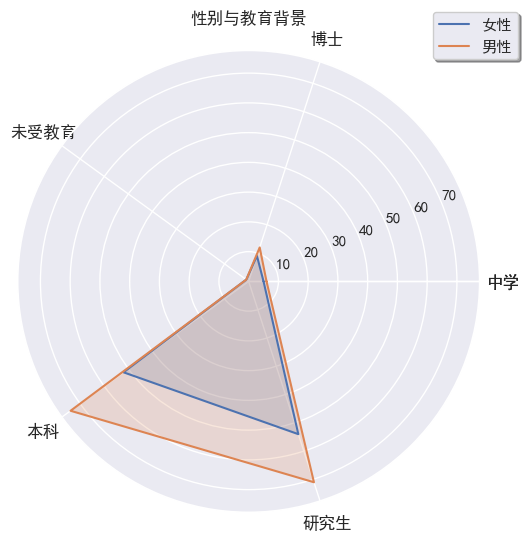

In [27]:
#获取性别与教育背景的数量关系
sex_jiaoyu = data.groupby(['性别','教育背景']).size().reset_index(name='数量')

#获取男性与女性不同教育背景的数量关系
f_sex_jiaoyu = sex_jiaoyu[sex_jiaoyu['性别']=='女性'].reset_index()
m_sex_jiaoyu = sex_jiaoyu[sex_jiaoyu['性别']=='男性'].reset_index()


#绘制雷达图
kinds = 5
plt.figure(figsize=(8,6),dpi=100)

#设置角度
angles = np.linspace(0,2*np.pi,kinds,endpoint=False)

#使雷达图封闭
f_sex_jiaoyu.loc[len(f_sex_jiaoyu)] = f_sex_jiaoyu.loc[0]
m_sex_jiaoyu.loc[len(m_sex_jiaoyu)] = m_sex_jiaoyu.loc[0]
angles = np.append(angles,angles[0])

data1 = [f_sex_jiaoyu['数量'].values.tolist(),m_sex_jiaoyu['数量'].values.tolist()]

sex = ['女性','男性']

for i,index in zip(data1,range(len(data1))):
    plt.polar(angles,i,label=sex[index])
    plt.fill(angles,i,alpha=0.2)
plt.thetagrids(angles*180/np.pi,f_sex_jiaoyu['教育背景'],fontproperties='simhei')

plt.title('性别与教育背景')

plt.legend(shadow=True,fancybox=True,bbox_to_anchor=[1.1,1.1])
plt.show()

<a id="4.5"></a>

## 4.5 各个属性与订单状态和反馈的情况

年龄与订单状态、反馈情况

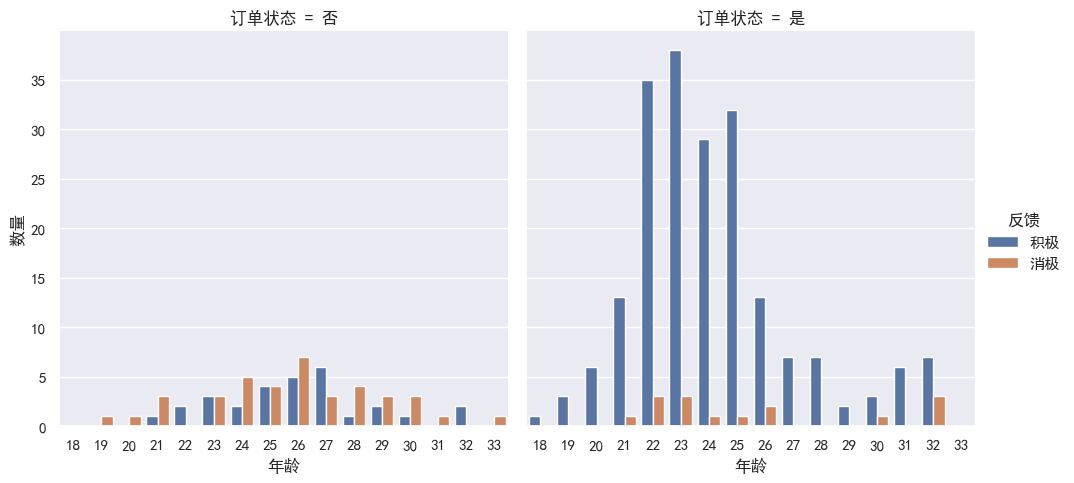

In [28]:
#获取订单状态、反馈和年龄之间的关系
age_output_feedback = data.groupby(['订单状态', '反馈','年龄']).size().reset_index(name='数量')

sns.catplot(x="年龄", y="数量", hue="反馈", col="订单状态", data=age_output_feedback, kind="bar")

# 显示图表
plt.show()

婚姻状态与订单状态，反馈的情况

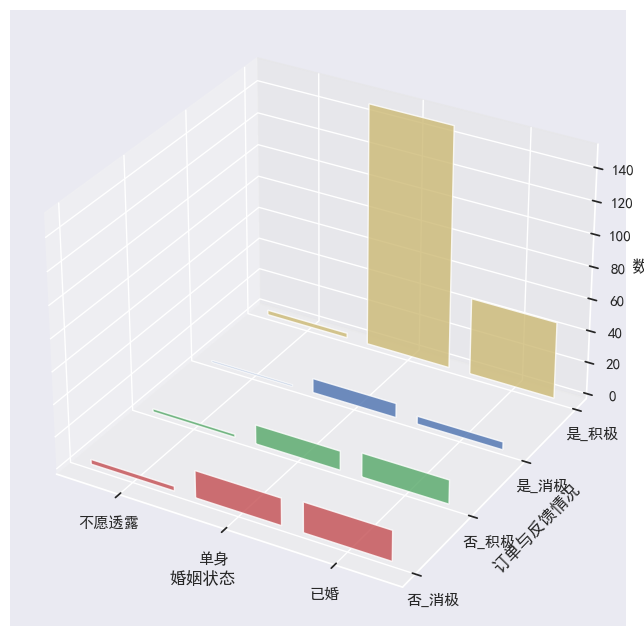

In [29]:
#获取订单状态、反馈和婚姻状态之间的关系
Mar_output_feedback = data.groupby(['订单状态', '反馈','婚姻状态']).size().reset_index(name='数量')

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(projection='3d')

#组合订单与反馈的情况并编码
Mar_output_feedback['订单_反馈'] = Mar_output_feedback['订单状态'].astype(str) + '_' + Mar_output_feedback['反馈']
Mar_output_feedback['订单_反馈_编码'] = pd.Categorical(Mar_output_feedback['订单_反馈']).codes

#对婚姻状态进行编码
Mar_output_feedback['婚姻状态_编码'] = pd.Categorical(Mar_output_feedback['婚姻状态']).codes

#设置柱形图颜色
colors = ['r','g','b','y']

#绘制
for z,color in zip(Mar_output_feedback['订单_反馈_编码'].unique(),colors):
    x = Mar_output_feedback[Mar_output_feedback['订单_反馈_编码']==z]['婚姻状态_编码']
    height = Mar_output_feedback[Mar_output_feedback['订单_反馈_编码']==z]['数量']
    ax.bar(x,height,zs=z,zdir='y',color=color,alpha=0.8)
ax.set_xlabel('婚姻状态')
ax.set_ylabel('订单与反馈情况')
ax.set_zlabel('数量')

# 获取唯一的状态和反馈标签
marriage_status_labels = Mar_output_feedback['婚姻状态'].unique()
order_feedback_labels = Mar_output_feedback['订单_反馈'].unique()

# 设置坐标轴刻度位置
ax.set_xticks(np.arange(len(marriage_status_labels)))
ax.set_yticks(np.arange(len(order_feedback_labels)))

# 设置坐标轴刻度标签
ax.set_xticklabels(marriage_status_labels)
ax.set_yticklabels(order_feedback_labels)

# 显示图形
plt.show()

月收入与订单状态、反馈的情况

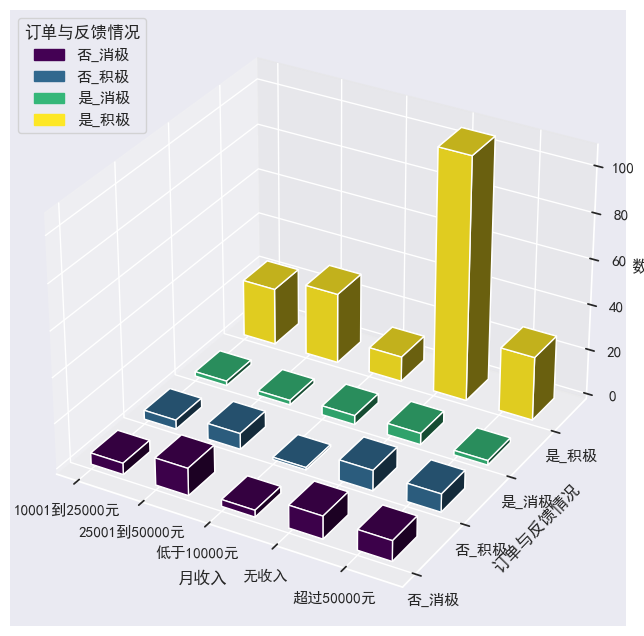

In [30]:
#获取三者之间的数量关系
shouru_output_feedback = data.groupby(['订单状态', '反馈','月收入']).size().reset_index(name='数量')

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')

# 对数据进行编码
shouru_output_feedback['订单_反馈'] = shouru_output_feedback['订单状态'].astype(str) + '_' + shouru_output_feedback['反馈']
shouru_output_feedback['订单_反馈_编码'] = pd.Categorical(shouru_output_feedback['订单_反馈']).codes
shouru_output_feedback['月收入_编码'] = pd.Categorical(shouru_output_feedback['月收入']).codes

# 获取唯一的状态和反馈标签
marriage_status_labels = shouru_output_feedback['月收入'].unique()
order_feedback_labels = shouru_output_feedback['订单_反馈'].unique()

# 创建一个颜色映射
colors = plt.cm.viridis(np.linspace(0, 1, len(order_feedback_labels)))

# 设置柱子的宽度和深度
dx = 0.5  # 柱子宽度
dy = 0.5  # 柱子深度

# 绘制3D长方体柱状图
for i, order_feedback in enumerate(order_feedback_labels):
    subset = shouru_output_feedback[shouru_output_feedback['订单_反馈'] == order_feedback]
    for j, marriage_status in enumerate(marriage_status_labels):
        if not subset.empty:
            data_point = subset[subset['月收入'] == marriage_status]
            if not data_point.empty:
                x = j  # 婚姻状态的编码作为x轴位置
                y = i  # 订单反馈的编码作为y轴位置
                z = 0  # z轴起点为0
                dz = data_point['数量'].values[0]  # 柱子高度
                ax.bar3d(x, y, z, dx, dy, dz, color=colors[i], shade=True)

# 设置坐标轴标签
ax.set_xlabel('月收入')
ax.set_ylabel('订单与反馈情况')
ax.set_zlabel('数量')

# 设置坐标轴刻度位置
ax.set_xticks(np.arange(len(marriage_status_labels)))
ax.set_yticks(np.arange(len(order_feedback_labels)))

# 设置坐标轴刻度标签
ax.set_xticklabels(marriage_status_labels)
ax.set_yticklabels(order_feedback_labels)


# 添加图例
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i in range(len(order_feedback_labels))]
ax.legend(handles, order_feedback_labels, loc='upper left', title='订单与反馈情况')

# 显示图形
plt.show()

教育背景与订单状态、反馈

In [31]:
# 创建时间轴
tl = Timeline()

#获取三者之间的数量关系
shouru_output_feedback = data.groupby(['订单状态', '反馈','教育背景']).size().reset_index(name='数量')

order_status = shouru_output_feedback['订单状态'].unique()
feedbacks = shouru_output_feedback['反馈'].unique()
education_levels = shouru_output_feedback['教育背景'].unique()

# 创建所有可能组合的 DataFrame
all_combinations = pd.DataFrame(list(product(order_status, feedbacks, education_levels)), columns=['订单状态', '反馈', '教育背景'])

#获取所有可能对应的数量
shouru_output_feedback1 = all_combinations.merge(shouru_output_feedback, how='left', on=['订单状态', '反馈', '教育背景']).fillna(0)
shouru_output_feedback1 = shouru_output_feedback1.sort_values(by='教育背景')

shouru_output_feedback_yes = shouru_output_feedback1[shouru_output_feedback1['订单状态']=='是']

#提取数据
x1 = shouru_output_feedback_yes['教育背景'].unique().tolist()
y11 = shouru_output_feedback_yes[shouru_output_feedback_yes['反馈']=='消极']['数量'].tolist()
y12 = shouru_output_feedback_yes[shouru_output_feedback_yes['反馈']=='积极']['数量'].tolist()

#绘图
bar1 = (
    Bar(init_opts=opts.InitOpts(theme=ThemeType.LIGHT))
    .add_xaxis(x1)
    .add_yaxis("消极", y11, stack="stack1")
    .add_yaxis("积极", y12, stack="stack1")
    .set_global_opts(title_opts=opts.TitleOpts("不同反馈"),
        yaxis_opts=opts.AxisOpts(name="数量",name_location="center",name_gap=30),
        xaxis_opts=opts.AxisOpts(name="教育背景",name_location="center",name_gap=30) 
    )
)

#向时间轴添加图标
tl.add(bar1,'订单状态为是')

shouru_output_feedback_no = shouru_output_feedback1[shouru_output_feedback1['订单状态']=='否']

x2 = shouru_output_feedback_no['教育背景'].unique().tolist()
y21 = shouru_output_feedback_no[shouru_output_feedback_no['反馈']=='消极']['数量'].tolist()
y22 = shouru_output_feedback_no[shouru_output_feedback_no['反馈']=='积极']['数量'].tolist()
bar2 = (
    Bar(init_opts=opts.InitOpts(theme=ThemeType.LIGHT))
    .add_xaxis(x2)
    .add_yaxis("消极", y21, stack="stack1")
    .add_yaxis("积极", y22, stack="stack1")
    .set_global_opts(title_opts=opts.TitleOpts("不同反馈"),
        yaxis_opts=opts.AxisOpts(name="数量",name_location="center",name_gap=30),
        xaxis_opts=opts.AxisOpts(name="教育背景",name_location="center",name_gap=30) 
    )
)

tl.add(bar2,'订单状态为否')
# 渲染页面
tl.render_notebook()  # 这将在当前目录下生成一个 HTML 文件

<a id="4.6"></a>

## 4.6 家庭人数、年龄与订单状态的关系

<Figure size 1200x600 with 0 Axes>

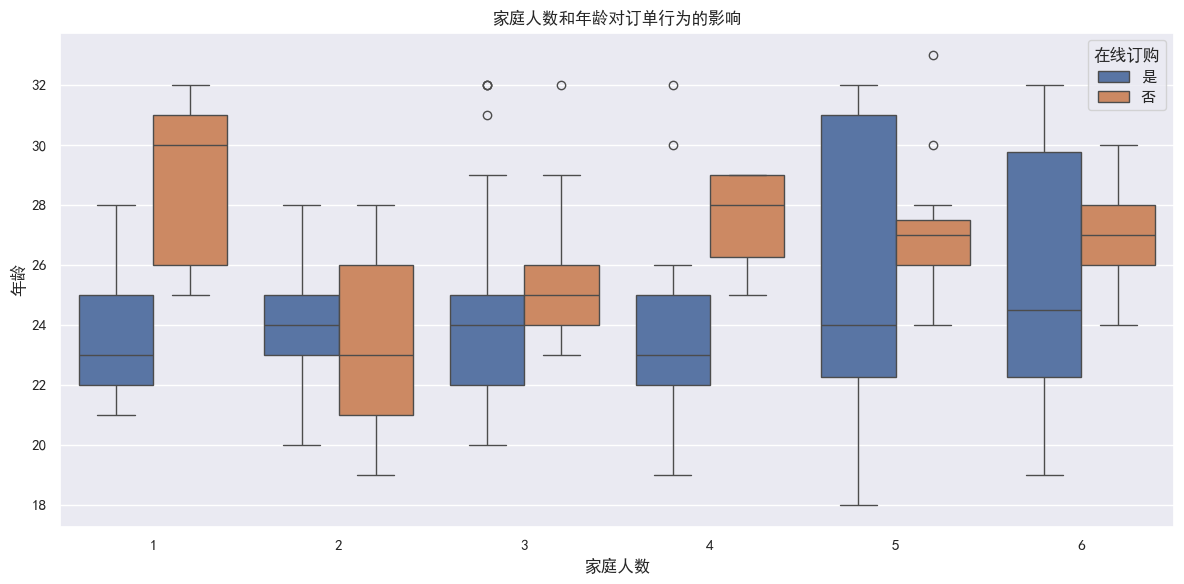

In [32]:
#绘制三者关系的箱线图
plt.figure(figsize=(12, 6))
plt.figure(figsize=(12, 6))
sns.boxplot(x='家庭人数', y='年龄', hue='订单状态', data=data)
plt.title('家庭人数和年龄对订单行为的影响')
plt.xlabel('家庭人数')
plt.ylabel('年龄')
plt.legend(title='在线订购')
plt.tight_layout()
plt.show()

<a id="5"></a>

# 5. 训练集测试集划分

In [33]:
data.head()
len(data)

285

In [34]:
#设置编码器并选择需要编码的列
encoder = LabelEncoder()
enc_col = ['性别', '婚姻状态', '职业', '月收入', '教育背景', '订单状态']

#编码
for feature in enc_col:
    data[feature] = encoder.fit_transform(data[feature])

#获取X和y
X = data.drop(['反馈','邮政编码'], axis=1)
y = encoder.fit_transform(data['反馈'])

# 拆分数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a id="6"></a>

# 6. 模型构建与拟合

In [35]:
# 构建随机森林模型
rf_model = RandomForestClassifier(n_estimators=5, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=42)

<a id="7"></a>

# 7. 模型预测与评估

<a id="7.1"></a>

## 7.1 模型预测

In [36]:
# 模型预测
y_pred = rf_model.predict(X_test)

<a id="7.2"></a>

## 7.2 模型评估

In [37]:
# 模型评估
accuracy_rf = accuracy_score(y_test, y_pred)
report_rf = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

# 打印混淆矩阵
print("Confusion Matrix:")
print(cm)

print(accuracy_rf)
print(report_rf)

Confusion Matrix:
[[ 4  3]
 [ 3 47]]
0.8947368421052632
              precision    recall  f1-score   support

           0       0.57      0.57      0.57         7
           1       0.94      0.94      0.94        50

    accuracy                           0.89        57
   macro avg       0.76      0.76      0.76        57
weighted avg       0.89      0.89      0.89        57



<a id="7.3"></a>

## 7.3 不同模型效果对比（随机森林与XGBoost）

In [38]:
# 构建 XGBoost 模型
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# 模型预测
y_pred = xgb_model.predict(X_test)

# 模型评估
accuracy_xgb = accuracy_score(y_test, y_pred)
report_xgb = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

# 打印混淆矩阵
print("Confusion Matrix:")
print(cm)

print(accuracy_xgb)
print(report_xgb)

Confusion Matrix:
[[ 3  4]
 [ 5 45]]
0.8421052631578947
              precision    recall  f1-score   support

           0       0.38      0.43      0.40         7
           1       0.92      0.90      0.91        50

    accuracy                           0.84        57
   macro avg       0.65      0.66      0.65        57
weighted avg       0.85      0.84      0.85        57



### 随机森林模型性能：
- **准确率 (Accuracy)**: 0.89
- **查准率 (Precision)**: 0.89
  - 类别 0：0.57
  - 类别 1：0.94
- **召回率 (Recall)**: 0.89
  - 类别 0：0.57
  - 类别 1：0.94
- **F1分数 (F1-score)**: 0.89
  - 类别 0：0.57
  - 类别 1：0.94

### XGBoost模型性能：
- **准确率 (Accuracy)**: 0.84
- **查准率 (Precision)**: 0.85
  - 类别 0：0.38
  - 类别 1：0.92
- **召回率 (Recall)**: 0.84
  - 类别 0：0.43
  - 类别 1：0.90
- **F1分数 (F1-score)**: 0.85
  - 类别 0：0.40
  - 类别 1：0.91

### 模型性能比较分析：

1. **准确率**：
   - 随机森林模型的准确率为 0.89，稍高于 XGBoost 模型的 0.84，表明在整体预测准确度上，随机森林略优于 XGBoost。

2. **查准率 (Precision)**：
   - 随机森林模型在类别 0 的查准率为 0.57，显著高于 XGBoost 的 0.38。
   - 在类别 1 上，随机森林模型的查准率为 0.94，高于 XGBoost 的 0.92。这表明随机森林在负例（类别0）上和正例（类别1）的预测准确性更好。

3. **召回率 (Recall)**：
   - 随机森林模型在类别 0 的召回率为 0.57，高于 XGBoost 的 0.43。
   - 在类别 1 上，两者的召回率都接近，随机森林为 0.94，XGBoost 为 0.90。这表明在捕捉正例（类别 1）方面两者表现接近，但随机森林在负例（类别 0）的召回率上优于 XGBoost。

4. **F1分数 (F1-score)**：
   - 随机森林模型在类别 0 和类别 1 的 F1 分数分别为 0.57 和 0.94。
   - XGBoost 模型在类别 0 和类别 1 的 F1 分数分别为 0.40 和 0.91。
   - 综合来看，随机森林在 F1 分数上的表现略优于 XGBoost，特别是在类别 0 的表现更为显著。

### 模型效果对比总结：
&ensp;&ensp;&ensp;&ensp;综合比较随机森林模型和XGBoost模型的性能指标，随机森林在大多数指标上都略优于XGBoost，尤其是在准确率和类别 0 的预测性能上表现更好。

### 改进方向：
- 提高模型训练的数据量。
- 尝试进一步调整模型的参数以提高模型的性能。
- 进行更多的特征工程，引入更多有助于模型性能提升的特征。
- 考虑使用集成方法。

<a id="7.4"></a>

## 7.4 模型预测结论

&ensp;&ensp;&ensp;&ensp;选用随机森林，该模型能有效识别用户反馈倾向，准确率达89.4%，尤其对积极用户群体的识别精确率高达94%，反映出在线订餐服务获得了较好的用户接受度，为业务优化提供了可靠的数据支撑，尽管数据不平衡问题仍是后续改进的重点。

<a id="8"></a>

# 8. 总结

&ensp;&ensp;&ensp;&ensp;基于对在线食品订单数据的深入分析和建模，本研究通过构建随机森林分类模型揭示了几个重要的趋势和洞察。首先，随着互联网技术的普及，消费者选择在线平台进行食品订单的趋势日益增长，这反映了消费行为的数字化转型。其次，通过数据科学和机器学习方法，我们构建的分类模型在预测用户反馈方面展现出较好的性能（准确率达89.4%），特别在对主要用户群体的识别上表现优异（精确率和召回率均达94%），这为企业优化产品推广和客户服务提供了数据支撑。<br>
&ensp;&ensp;&ensp;&ensp;在模型分析方面，研究发现模型能够有效识别影响用户反馈的关键因素，通过对性别、婚姻状态、职业、月收入等特征的编码和分析，为理解不同用户群体的行为模式提供了依据。然而，需要指出的是，由于数据中存在明显的类别不平衡现象，模型结果需结合业务实际谨慎解读。从预测分布来看，用户反馈以积极倾向为主，这在一定程度上反映了在线订餐服务在市场上的接受度。<br>
&ensp;&ensp;&ensp;&ensp;最后，通过本次研究，我们小组的几位成员在数据处理、特征工程、模型构建与评估等环节积累了宝贵经验，特别是在处理真实业务数据和解决类别不平衡问题方面有了更深入的理解，为后续的数据分析工作奠定了实践基础。